## Objective

The goal of this notebook is to define customer churn based on behavioral inactivity, engineer meaningful customer-level features, and prepare a final dataset for churn prediction modeling.

## Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load the datasets

In [2]:
df = pd.read_excel("C:/Projects/09_Customer_churn_predictor/data/Online Retail.xlsx")
customer_df = pd.read_csv("C:/Projects/09_Customer_churn_predictor/data/customer_features.csv")

In [3]:
customer_df.head()

,CustomerID,Frequency,TotalQuantity,Monetary,LastPurchase,Recency
0,12346.0,1,74215,77183.60,2011-01-18 10:01:00,325
1,12347.0,7,2458,4310.00,2011-12-07 15:52:00,1
2,12348.0,4,2341,1797.24,2011-09-25 13:13:00,74
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,18
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309


In [4]:
# Check the column names
customer_df.columns

Index(['CustomerID', 'Frequency', 'TotalQuantity', 'Monetary', 'LastPurchase',
       'Recency'],
      dtype='object')

In [5]:
# Check the dataset shape
customer_df.shape

(4338, 6)

In [6]:
# Check the data types
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     4338 non-null   float64
 1   Frequency      4338 non-null   int64  
 2   TotalQuantity  4338 non-null   int64  
 3   Monetary       4338 non-null   float64
 4   LastPurchase   4338 non-null   object 
 5   Recency        4338 non-null   int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 203.5+ KB


In [7]:
# Check the missing values
customer_df.isnull().sum()

CustomerID       0
Frequency        0
TotalQuantity    0
Monetary         0
LastPurchase     0
Recency          0
dtype: int64

In [8]:
customer_df['Recency'].describe()

count    4338.000000
mean       91.536422
std       100.014169
min         0.000000
25%        17.000000
50%        50.000000
75%       141.000000
max       373.000000
Name: Recency, dtype: float64

## Plot Recency distribution

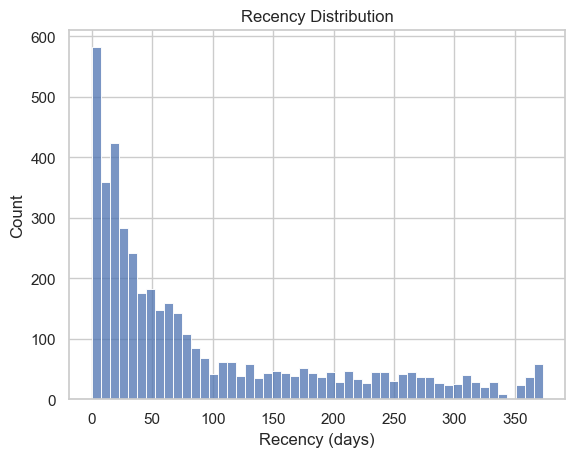

In [9]:
sns.histplot(customer_df["Recency"],bins=50)
plt.title("Recency Distribution")
plt.xlabel("Recency (days)")
plt.ylabel("Count")
plt.show()

This plot is the right-skewed where most customers have made a purchase within the last 50 days but the long tail shows that there are still cutsomers who didn't buy 300 days.

In [11]:
# Check recency percentiles
customer_df['Recency'].quantile([0.25,0.50,0.75,0.90,0.95,0.99])

0.25     17.0
0.50     50.0
0.75    141.0
0.90    262.0
0.95    311.0
0.99    368.0
Name: Recency, dtype: float64

In [13]:
# Choose churn threshold
churn_threshold = customer_df["Recency"].quantile(0.75)
churn_threshold

np.float64(141.0)

In [15]:
# Create churn column
customer_df["Churn"] = (customer_df["Recency"]> churn_threshold).astype(int)
customer_df["Churn"].head()

0    1
1    0
2    0
3    0
4    1
Name: Churn, dtype: int64

In [16]:
# Check unique churn values
customer_df["Churn"].unique()

array([1, 0])

In [17]:
# Check churn counts
customer_df["Churn"].value_counts()

Churn
0    3254
1    1084
Name: count, dtype: int64

In [18]:
# Check churn percentage
customer_df["Churn"].value_counts(normalize=True) * 100

Churn
0    75.011526
1    24.988474
Name: proportion, dtype: float64

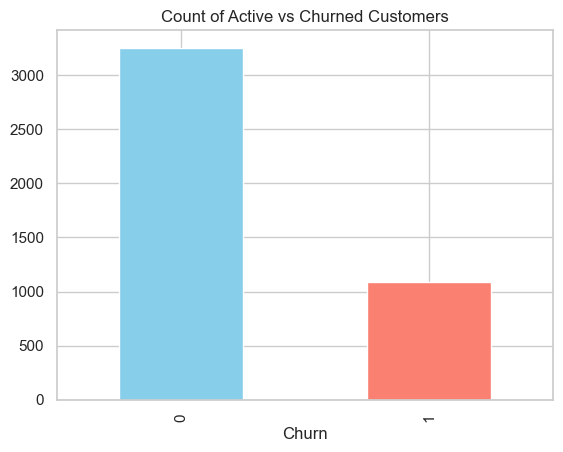

In [ ]:
# Plot churn distribution
customer_df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Count of Active vs Churned Customers')
plt.show()

In [21]:
# Create Average Order Value
customer_df["AvgOrderValue"] = customer_df["Monetary"]/customer_df["Frequency"]

In [22]:
customer_df[["Frequency", "Monetary", "AvgOrderValue"]].head()

,Frequency,Monetary,AvgOrderValue
0,1,77183.60,77183.600000
1,7,4310.00,615.714286
2,4,1797.24,449.310000
3,1,1757.55,1757.550000
4,1,334.40,334.400000


In [23]:
# Create Purchase Intensity
customer_df["PurchaseIntensity"] = customer_df["Frequency"] / (customer_df["Recency"] + 1)

In [24]:
# Check
customer_df[["Frequency", "Recency", "PurchaseIntensity"]].head()

,Frequency,Recency,PurchaseIntensity
0,1,325,0.003067
1,7,1,3.500000
2,4,74,0.053333
3,1,18,0.052632
4,1,309,0.003226


## Original Transactional dataset

In [ ]:
# Convert datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [26]:
# Data cleaining
df = df.dropna(subset=["CustomerID"])
df = df.dropna(subset=["Description"])


In [27]:
# Keep only positive
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [28]:
# Define reference date
reference_date = df["InvoiceDate"].max()
reference_date 

Timestamp('2011-12-09 12:50:00')

In [29]:
# Compute first purchase date per customer
first_purchase = df.groupby("CustomerID")["InvoiceDate"].min()
first_purchase.head()

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2010-12-07 14:57:00
12348.0   2010-12-16 19:09:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[ns]

In [33]:
## set customer Id as index
customer_df.set_index("CustomerID", inplace=True)

In [34]:
# create customer lifetime
customer_df["CustomerLifetime"] = customer_df.index.map(
    lambda x: (reference_date - first_purchase.loc[x]).days
)
customer_df[["CustomerLifetime"]].head()

,CustomerLifetime
CustomerID,
12346.0,325
12347.0,366
12348.0,357
12349.0,18
12350.0,309


In [35]:
# Check null again
customer_df.isnull().sum()

Frequency            0
TotalQuantity        0
Monetary             0
LastPurchase         0
Recency              0
Churn                0
AvgOrderValue        0
PurchaseIntensity    0
CustomerLifetime     0
dtype: int64

## Boxplot: Recency vs Churn

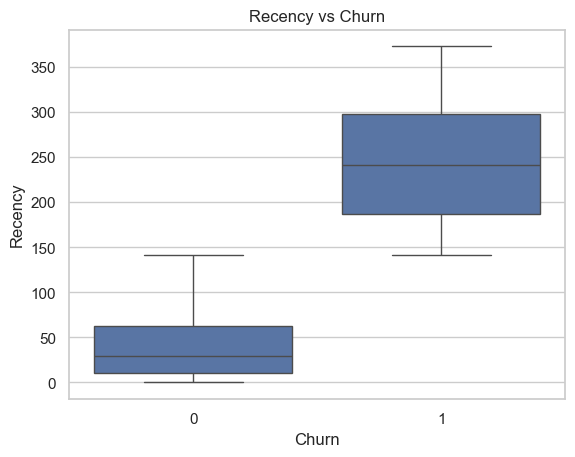

In [36]:
sns.boxplot(x="Churn", y="Recency", data=customer_df)
plt.title("Recency vs Churn")
plt.xlabel("Churn")
plt.ylabel("Recency")
plt.show()

# Boxplot: Frequency vs Churn

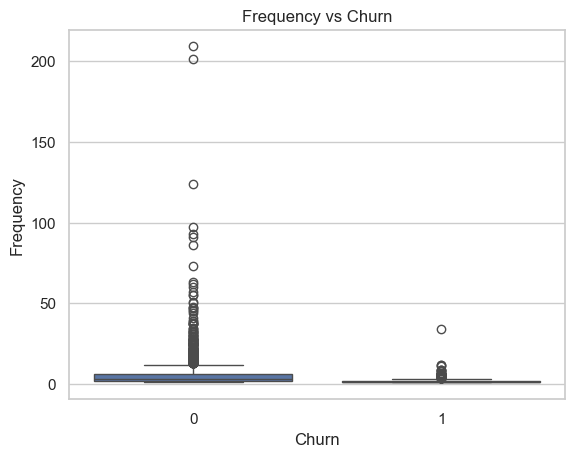

In [37]:
sns.boxplot(x="Churn", y="Frequency", data=customer_df)
plt.title("Frequency vs Churn")
plt.xlabel("Churn")
plt.ylabel("Frequency")
plt.show()

## Boxplot: Monetary vs Churn

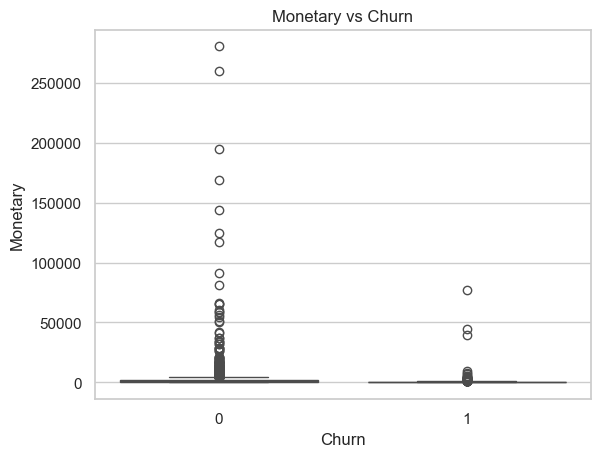

In [38]:
sns.boxplot(x="Churn", y="Monetary", data=customer_df)
plt.title("Monetary vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monetary")
plt.show()

## Boxplot: AvgOrderValue vs Churn

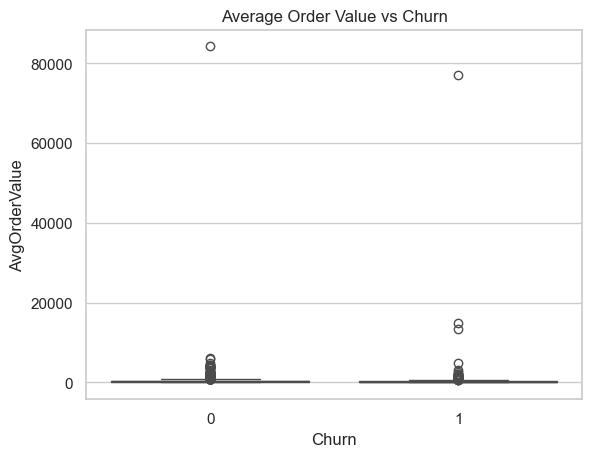

In [39]:
sns.boxplot(x="Churn", y="AvgOrderValue", data=customer_df)
plt.title("Average Order Value vs Churn")
plt.xlabel("Churn")
plt.ylabel("AvgOrderValue")
plt.show()

## Boxplot: PurchaseIntensity vs Churn

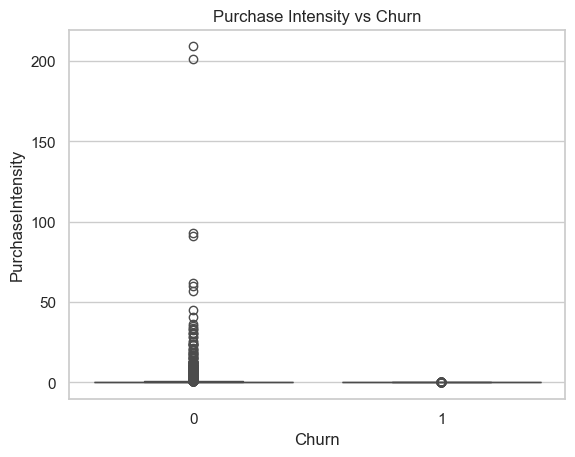

In [40]:
sns.boxplot(x="Churn", y="PurchaseIntensity", data=customer_df)
plt.title("Purchase Intensity vs Churn")
plt.xlabel("Churn")
plt.ylabel("PurchaseIntensity")
plt.show()

## Boxplot: CustomerLifetime vs Churn

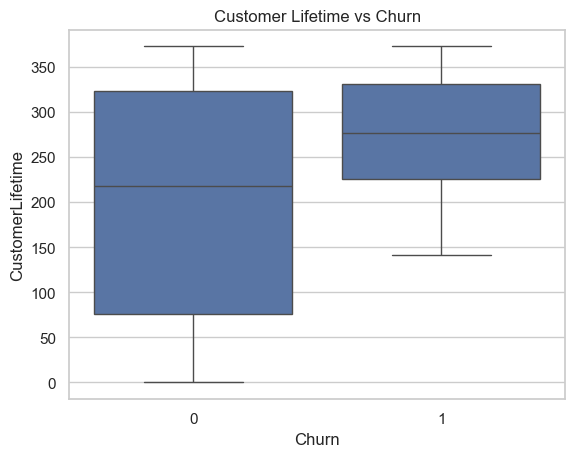

In [41]:
sns.boxplot(x="Churn", y="CustomerLifetime", data=customer_df)
plt.title("Customer Lifetime vs Churn")
plt.xlabel("Churn")
plt.ylabel("CustomerLifetime")
plt.show()

In [42]:
# Check summary statistics by churn group
customer_df.groupby("Churn")[["Recency", "Frequency", "Monetary", "AvgOrderValue", "PurchaseIntensity", "CustomerLifetime"]].mean()

,Recency,Frequency,Monetary,AvgOrderValue,PurchaseIntensity,CustomerLifetime
Churn,,,,,,
0,40.086663,5.153350,2521.262997,421.625145,1.089552,204.485556
1,245.980627,1.626384,652.415232,411.785188,0.007471,275.809041


In [43]:
# Check median statistics by churn group
customer_df.groupby("Churn")[["Recency", "Frequency", "Monetary", "AvgOrderValue", "PurchaseIntensity", "CustomerLifetime"]].median()


,Recency,Frequency,Monetary,AvgOrderValue,PurchaseIntensity,CustomerLifetime
Churn,,,,,,
0,29.0,3.0,920.79,306.97375,0.100000,218.0
1,241.0,1.0,311.76,233.33125,0.004739,277.0


In [44]:
# Correlation Matrix
corr_matrix = customer_df[["Recency", "Frequency", "Monetary", "AvgOrderValue", "PurchaseIntensity", "CustomerLifetime", "Churn"]].corr()
corr_matrix

,Recency,Frequency,Monetary,AvgOrderValue,PurchaseIntensity,CustomerLifetime,Churn
Recency,1.000000,-0.260578,-0.122097,-0.000276,-0.125593,0.272267,0.891386
Frequency,-0.260578,1.000000,0.553650,0.019063,0.823618,0.313297,-0.198384
Monetary,-0.122097,0.553650,1.000000,0.393479,0.429256,0.149501,-0.090019
AvgOrderValue,-0.000276,0.019063,0.393479,1.000000,0.015047,0.009286,-0.002372
PurchaseIntensity,-0.125593,0.823618,0.429256,0.015047,1.000000,0.122685,-0.082259
CustomerLifetime,0.272267,0.313297,0.149501,0.009286,0.122685,1.000000,0.261971
Churn,0.891386,-0.198384,-0.090019,-0.002372,-0.082259,0.261971,1.000000


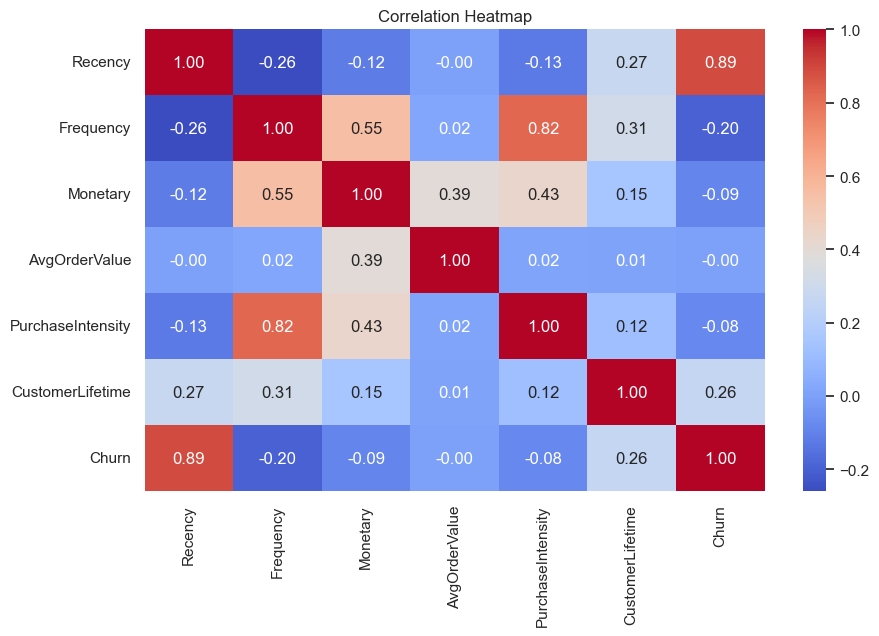

In [45]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Save the final dataset

In [47]:
customer_df.to_csv("C:/Projects/09_Customer_churn_predictor/data/final_churn_dataset.csv")

## Churn Definition

Since the dataset does not provide an explicit churn label, churn is defined using a recency-based business rule. Customers whose recency is above the 75th percentile are labeled as churned, while the rest are labeled as active. This data-driven threshold was chosen because a fixed 90-day rule did not produce meaningful class separation in this dataset.

## Feature Engineering

To improve the predictive power of the dataset, several additional behavioral features were created. Average Order Value captures the average amount spent per order, Purchase Intensity reflects how frequently a customer buys relative to their inactivity period, and Customer Lifetime measures how long the customer has been active in the dataset. These features complement the original RFM variables and provide richer behavioral signals for churn prediction.

## Key Insights

The analysis shows that churned customers generally have higher recency, lower frequency, and lower purchase intensity than active customers. Monetary value may also differ across groups, indicating that more engaged and valuable customers are less likely to churn. Customer lifetime provides additional context, helping distinguish newer customers from long-term customers who have become inactive.